# Myristoylation (DesB30 -> Detemir) 5 L Tank Mechanistic Model — Process Optimization
Full 9-species regiochemistry (mono/di/tri-acylation at A1, B1, B29) + NHS-ester hydrolysis + dynamic glycine quench,
coupled to a 3-compartment hydrodynamic model of a 5 L reactor (3086.1768 mL working volume).

**Process control strategy implemented here:**
- NHS-Myr delivered as a **continuous timed feed** (peristaltic pump, volumetric-rate controlled) instead of an instant spike, to slow the reaction to a controllable working time.
- **Time-varying tank volume** during dosing (NHS-Myr stock adds meaningful volume — properly tracked via a moles-based state, not concentration, so dilution is handled exactly).
- Reaction is allowed to run to its **Detemir concentration peak** (best yield before secondary over-acylation erodes it), which triggers the glycine quench.
- Glycine dose is **dynamically sized** (1.1x molar excess over residual NHS-Myr at the peak) rather than a fixed large excess, to avoid adding unnecessary quenching reagent.
- The full acylation/hydrolysis network keeps running during the quench stage (not just NHS+glycine) since all reactive species are still present and NHS hasn't hit zero.

In [1]:
# --- TOP CELL: RUN THIS ONCE ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import dill
import os
# -------------------------------

## 1. Stoichiometry & process parameters
DesB30 corrected to **2 mg/mL** (was 4 mg/mL). NHS-Myr stock at 0.482 mg/mL (unchanged).
Impeller fixed at **450 rpm** (found to have no measurable effect on yield/selectivity across the 200-450 rpm range tested — this system's reaction is feed-rate-limited, not mixing-limited).

In [2]:
MW_desb30 = 5706.0
MW_nhs_myr = 325.44
MW_glycine = 75.07

V_total_mix_mL = 3086.1768
V_buffer_L = (V_total_mix_mL / 2.0) / 1000.0
V_acn_L    = (V_total_mix_mL / 2.0) / 1000.0

DESB30_STOCK_MG_ML = 2.0   # UPDATED per researcher (was 4.0)
NHS_STOCK_MG_ML    = 0.482
GLY_STOCK_G_ML     = 2.0

mass_desb30_mg = DESB30_STOCK_MG_ML * (V_buffer_L * 1000.0)
moles_desb30_mmol = mass_desb30_mg / MW_desb30
moles_nhs_mmol = moles_desb30_mmol * 2.0
V_nhs_add_L = ((moles_nhs_mmol * MW_nhs_myr) / NHS_STOCK_MG_ML) / 1000.0

N_RPM = 450.0

print(f'DesB30: {moles_desb30_mmol:.5f} mmol | NHS-Myr: {moles_nhs_mmol:.5f} mmol | '
      f'V_nhs_add: {V_nhs_add_L*1000:.1f} mL ({V_nhs_add_L/V_buffer_L*100:.1f}% of pre-dose buffer volume)')

DesB30: 0.54087 mmol | NHS-Myr: 1.08173 mmol | V_nhs_add: 730.4 mL (47.3% of pre-dose buffer volume)


## 2. Kinetics (9-species regiochemistry + hydrolysis)
Loaded from `30jul2026_hydrolysis_kinetic_model.dill` (`model.k[0..7]`, fit in per-Molar per-minute, n=m=1).
Glycine quench reuses **k[0]** (desb30 -> A1) as an SME-specified proxy, since A1 is the desb30 N-terminal glycine.

In [3]:
SPECIES = ['ACN', 'nhs_myr', 'desb30', 'A1', 'detemir', 'B1',
           'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1', 'glycine', 'gly_myr']
IDX = {name: i for i, name in enumerate(SPECIES)}
N_SPECIES = len(SPECIES)
N_COMPARTMENTS = 3
REACTIVE_SPECIES = ['nhs_myr', 'desb30', 'A1', 'detemir', 'B1',
                     'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1', 'glycine', 'gly_myr']

def load_kinetics(path='30jul2026_hydrolysis_kinetic_model.dill'):
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        model = bundle['model_instance']
        k = list(model.k)
        n, m = model.n, model.m
        print(f"SUCCESS: Loaded '{bundle.get('description')}' (SSE={bundle.get('final_sse'):.4f})")
        print(f'k = {k}')
    except Exception as e:
        print(f'WARNING: Using fallback parameters ({e}).')
        k = [128.09722809146817, 983.8538887266628, 3482.7300303640786,
             0.09647988709435266, 0.21198823727930952, 102.64734526883088,
             6523.411560711998, 0.08282632221838386]
        n, m = 1.0, 1.0
    return k, n, m

k, order_n, order_m = load_kinetics()
k_quench = k[0]  # glycine-quench proxy

SUCCESS: Loaded 'Hydrolysis-included mechanistic model' (SSE=3.9837)
k = [128.09722809146817, 983.8538887266628, 3482.7300303640786, 0.09647988709435266, 0.21198823727930952, 102.64734526883088, 6523.411560711998, 0.08282632221838386]


## 3. Dimensional bridge & reaction network

In [4]:
def calc_rate_mM_s(k_per_min, c_nhs_mM, c_sub_mM):
    c_nhs_M = max(0.0, c_nhs_mM/1000.0); c_sub_M = max(0.0, c_sub_mM/1000.0)
    if c_nhs_M <= 1e-12 or c_sub_M <= 1e-12: return 0.0
    return k_per_min * (c_nhs_M**order_n) * (c_sub_M**order_m) * (1000.0/60.0)

def calc_hydro_rate_mM_s(k_per_min, c_nhs_mM):
    c_nhs_M = max(0.0, c_nhs_mM/1000.0)
    if c_nhs_M <= 1e-12: return 0.0
    return k_per_min * c_nhs_M * (1000.0/60.0)

def reaction_derivs_mM_s(C, k, k_quench):
    """C: dict of one compartment's concentrations (mM). Returns dict of d(conc)/dt (mM/s)."""
    NHS=C['nhs_myr']; DESB=C['desb30']; A1=C['A1']; DET=C['detemir']; A1B29=C['A1_B29']; GLY=C['glycine']

    r1 = calc_rate_mM_s(k[0], NHS, DESB)   # desb30 + NHS -> A1
    r2 = calc_rate_mM_s(k[1], NHS, DESB)   # desb30 + NHS -> B1
    r3 = calc_rate_mM_s(k[2], NHS, DESB)   # desb30 + NHS -> detemir (B29)
    r4 = calc_rate_mM_s(k[3], NHS, A1)     # A1 + NHS -> A1_B1
    r5 = calc_rate_mM_s(k[4], NHS, A1)     # A1 + NHS -> A1_B29
    r6 = calc_rate_mM_s(k[5], NHS, DET)    # detemir + NHS -> B1_B29
    r7 = calc_rate_mM_s(k[6], NHS, A1B29)  # A1_B29 + NHS -> A1_B29_B1
    r_hydro  = calc_hydro_rate_mM_s(k[7], NHS)      # NHS -> dead (hydrolysis)
    r_quench = calc_rate_mM_s(k_quench, NHS, GLY)   # NHS + glycine -> gly_myr

    d = {}
    d['nhs_myr']   = -(r1+r2+r3+r4+r5+r6+r7) - r_hydro - r_quench
    d['desb30']    = -(r1+r2+r3)
    d['A1']        = r1 - (r4+r5)
    d['B1']        = r2
    d['detemir']   = r3 - r6
    d['A1_B1']     = r4
    d['A1_B29']    = r5 - r7
    d['B1_B29']    = r6
    d['A1_B29_B1'] = r7
    d['glycine']   = -r_quench
    d['gly_myr']   = r_quench    # myristoylated glycine (quenched byproduct)
    return d

## 4. Hydrodynamics (3-compartment, impeller-driven mixing)

In [5]:
def calc_compartments(V_current_L, N_rpm=N_RPM):
    Area_tank = np.pi*(0.205/2)**2
    H_fluid = (V_current_L/1000.0)/Area_tank
    baffle_factor = 0.1
    N_rps = N_rpm/60.0
    Q_L_s = (0.5*baffle_factor*N_rps*(0.075**3))*1000.0
    h_ratio = 0.02/H_fluid
    V2_L = (np.pi*(0.075/2)**2*(0.3*0.075))*1000.0
    V3_L = max(0.01, V_current_L*h_ratio - V2_L/2)
    V1_L = max(0.01, V_current_L - V2_L - V3_L)
    Q12 = Q_L_s*(h_ratio/0.33); Q23 = Q_L_s*((1.0-h_ratio)/0.67)
    return V1_L, V2_L, V3_L, Q12, Q23

## 5. Moles-based transport
Switched the state representation from **concentration** to **total moles per compartment**. This is what correctly handles a *time-varying* tank volume (the NHS-Myr feed adds ~24%+ extra volume during dosing) without needing extra dilution-correction terms: moles are conserved through transport and volume changes automatically; concentration is only reconstructed (moles / current volume) when evaluating rate laws.

In [6]:
def transport_moles(row_moles, V1, V2, V3, Q12, Q23):
    N1, N2, N3 = row_moles
    C1, C2, C3 = N1/V1, N2/V2, N3/V3
    f12 = Q12*(C1-C2); f23 = Q23*(C2-C3)
    return np.array([-f12, f12-f23, f23])

## 6. Stage 1: ACN/buffer mixing

In [7]:
def run_stage_1():
    V_tot = V_buffer_L + V_acn_L
    V1, V2, V3, Q12, Q23 = calc_compartments(V_tot)
    C_des_init = moles_desb30_mmol / V_tot
    y0 = np.zeros((N_SPECIES, N_COMPARTMENTS))
    y0[IDX['ACN']] = np.array([1.0, 0.0, 0.0]) * np.array([V1, V2, V3])
    y0[IDX['desb30']] = C_des_init * np.array([V1, V2, V3])

    def ode(t, yf):
        y = yf.reshape(N_SPECIES, N_COMPARTMENTS); dydt = np.zeros_like(y)
        dydt[IDX['ACN']] = transport_moles(y[IDX['ACN']], V1, V2, V3, Q12, Q23)
        return dydt.flatten()

    sol = solve_ivp(ode, [0, 60], y0.flatten(), max_step=0.5)
    return sol.y[:, -1].reshape(N_SPECIES, N_COMPARTMENTS), V_tot

## 7. Stage 2: dosed NHS-Myr feed + reaction (time-varying volume)
NHS-Myr is fed at a **constant molar rate** into zone 1 over `T_feed` minutes; tank volume grows continuously during dosing and compartment geometry (`V1,V2,V3,Q12,Q23`) is recomputed at every ODE evaluation from the current cumulative volume.

In [8]:
def run_stage_2_dosed(y_initial_moles, V_start, T_feed_min, t_hold_s=2200.0, N_rpm=N_RPM):
    T_feed_s = T_feed_min * 60.0
    feed_rate_mmol_s = moles_nhs_mmol / T_feed_s

    def get_geom(t):
        V_added = min(t, T_feed_s) / T_feed_s * V_nhs_add_L
        return calc_compartments(V_start + V_added, N_rpm)

    y0 = y_initial_moles.copy()  # moles carry straight through stage boundaries

    def ode(t, yf):
        y = np.maximum(0.0, yf).reshape(N_SPECIES, N_COMPARTMENTS)
        V1, V2, V3, Q12, Q23 = get_geom(t)
        Vvec = np.array([V1, V2, V3])
        dydt = np.zeros_like(y)
        for j in range(N_COMPARTMENTS):
            Cj = {name: y[IDX[name], j] / Vvec[j] for name in REACTIVE_SPECIES}
            d = reaction_derivs_mM_s(Cj, k, k_quench)
            for name, val_mM_s in d.items():
                dydt[IDX[name], j] += val_mM_s * Vvec[j]
        for name in REACTIVE_SPECIES:
            dydt[IDX[name]] += transport_moles(y[IDX[name]], V1, V2, V3, Q12, Q23)
        if t < T_feed_s:
            dydt[IDX['nhs_myr'], 0] += feed_rate_mmol_s
        return dydt.flatten()

    sol = solve_ivp(ode, [0, t_hold_s], y0.flatten(), method='BDF', dense_output=True, max_step=2.0)
    return sol, V_start

def detemir_peak_time_min(T_feed_min, y_mix, V1_, t_hold_s=2200.0, grid_n=2200):
    sol, V_start = run_stage_2_dosed(y_mix, V1_, T_feed_min, t_hold_s)
    t_grid = np.linspace(0, t_hold_s, grid_n)
    y_grid = sol.sol(t_grid).reshape(N_SPECIES, N_COMPARTMENTS, -1)
    T_feed_s = T_feed_min * 60.0
    det_conc = np.zeros(grid_n)
    for i, t in enumerate(t_grid):
        V_added = min(t, T_feed_s) / T_feed_s * V_nhs_add_L
        V1c, _, _, _, _ = calc_compartments(V_start + V_added)
        det_conc[i] = y_grid[IDX['detemir'], 0, i] / V1c
    pk = np.argmax(det_conc)
    return t_grid[pk] / 60.0, sol, V_start, t_grid, y_grid, pk

## 8. Solve for T_feed (target: 30 min Detemir peak, bounded 1-30 min)
`t_peak` increases monotonically with `T_feed` across the whole allowed range but tops out at ~25.8 min at `T_feed = 30 min` (the pump-duration bound) -- a true 30 min peak would need `T_feed ≈ 36 min`, outside the agreed 1-30 min window. Per confirmation, we keep the hard bound and use the closest achievable point: **`T_feed = 30 min`**.

**Important operational consequence:** the Detemir peak (25.8 min) falls *before* a 30-minute feed would finish delivering. That means in practice **the pump must be stopped early** -- around 25.8 min in -- rather than being allowed to run its full nominal 30-minute program. This delivers only ~86% of the planned NHS-Myr charge (~1.72x molar excess instead of the intended 2.0x). Worth confirming with your researcher whether an early, timed pump stop is operationally workable, or whether the charge/excess should be revisited so the full intended dose lines up with the quench trigger.

In [9]:
T_FEED_MIN = 30.0   # nominal pump-duration SEARCH BOUND, not necessarily the actual stop time

y_mix, V1_ = run_stage_1()
t_peak_min, sol2, V_start2, t_grid2, y_grid2, pk = detemir_peak_time_min(T_FEED_MIN, y_mix, V1_)
pct_delivered = t_peak_min / T_FEED_MIN * 100
print(f'T_feed (nominal pump setting) = {T_FEED_MIN} min')
print(f'Detemir peak reached at t = {t_peak_min:.2f} min -- BEFORE the nominal feed would finish')
print(f'>>> Pump must be stopped early, at t = {t_peak_min:.2f} min, delivering only '
      f'{pct_delivered:.1f}% of the planned NHS-Myr charge ({pct_delivered/100*2:.2f}x molar excess instead of 2.0x) <<<')

y_peak_moles = y_grid2[:, :, pk]
T_feed_s = T_FEED_MIN * 60.0
V_added_at_peak = min(t_peak_min*60.0, T_feed_s) / T_feed_s * V_nhs_add_L
V_at_peak = V_start2 + V_added_at_peak   # ACTUAL tank volume at the quench trigger moment


T_feed (nominal pump setting) = 30.0 min
Detemir peak reached at t = 25.76 min -- BEFORE the nominal feed would finish
>>> Pump must be stopped early, at t = 25.76 min, delivering only 85.9% of the planned NHS-Myr charge (1.72x molar excess instead of 2.0x) <<<


## 9. Stage 3: dynamic glycine quench
Glycine dosed at **1.1x molar excess over residual NHS-Myr present at the Detemir peak** (summed across all 3 compartments) -- not the original fixed full-excess charge. The full acylation/hydrolysis network keeps running alongside the quench reaction.

In [10]:
def run_stage_3_quench(y_state_moles, V_start, t_quench_s=1200.0, N_rpm=N_RPM, excess_factor=1.1):
    N_nhs_total = y_state_moles[IDX['nhs_myr']].sum()
    dose_gly_mmol = excess_factor * N_nhs_total
    V_gly_add_L = ((dose_gly_mmol * MW_glycine) / GLY_STOCK_G_ML) / 1000.0

    V_tot = V_start + V_gly_add_L
    V1, V2, V3, Q12, Q23 = calc_compartments(V_tot, N_rpm)

    y0 = y_state_moles.copy()
    y0[IDX['glycine'], 0] += dose_gly_mmol

    def ode(t, yf):
        y = np.maximum(0.0, yf).reshape(N_SPECIES, N_COMPARTMENTS)
        dydt = np.zeros_like(y)
        for j in range(N_COMPARTMENTS):
            Cj = {name: y[IDX[name], j] / [V1, V2, V3][j] for name in REACTIVE_SPECIES}
            d = reaction_derivs_mM_s(Cj, k, k_quench)
            for name, val in d.items():
                dydt[IDX[name], j] += val * [V1, V2, V3][j]
        for name in REACTIVE_SPECIES:
            dydt[IDX[name]] += transport_moles(y[IDX[name]], V1, V2, V3, Q12, Q23)
        return dydt.flatten()

    sol = solve_ivp(ode, [0, t_quench_s], y0.flatten(), method='BDF', dense_output=True, max_step=2.0)
    return sol, V_tot, dose_gly_mmol, N_nhs_total

sol3, V_tot3, dose_gly_mmol, nhs_residual = run_stage_3_quench(y_peak_moles, V_at_peak)
print(f'Residual NHS-Myr at peak (mmol): {nhs_residual:.5f}')
print(f'Glycine dose (1.1x excess, mmol): {dose_gly_mmol:.5f} '
      f'({dose_gly_mmol*MW_glycine/GLY_STOCK_G_ML*1000:.2f} uL of {GLY_STOCK_G_ML} g/mL stock)')

Residual NHS-Myr at peak (mmol): 0.19777
Glycine dose (1.1x excess, mmol): 0.21755 (8165.70 uL of 2.0 g/mL stock)


## 10. Mass balance check

In [11]:
V1f, V2f, V3f, _, _ = calc_compartments(V_tot3)
final_state = sol3.y[:, -1].reshape(N_SPECIES, N_COMPARTMENTS)
protein_species = ['desb30','A1','detemir','B1','A1_B29','B1_B29','A1_B1','A1_B29_B1']
total_protein = sum(final_state[IDX[s]].sum() for s in protein_species)
print(f'Protein mass balance: {total_protein:.6f} mmol vs initial {moles_desb30_mmol:.6f} mmol '
      f'(ratio={total_protein/moles_desb30_mmol:.6f})')
print(f'Gly-Myr (quenched byproduct) formed: {final_state[IDX["gly_myr"]].sum():.5f} mmol')

Protein mass balance: 0.540865 mmol vs initial 0.540865 mmol (ratio=1.000000)
Gly-Myr (quenched byproduct) formed: 0.01127 mmol


## 11. Visualization

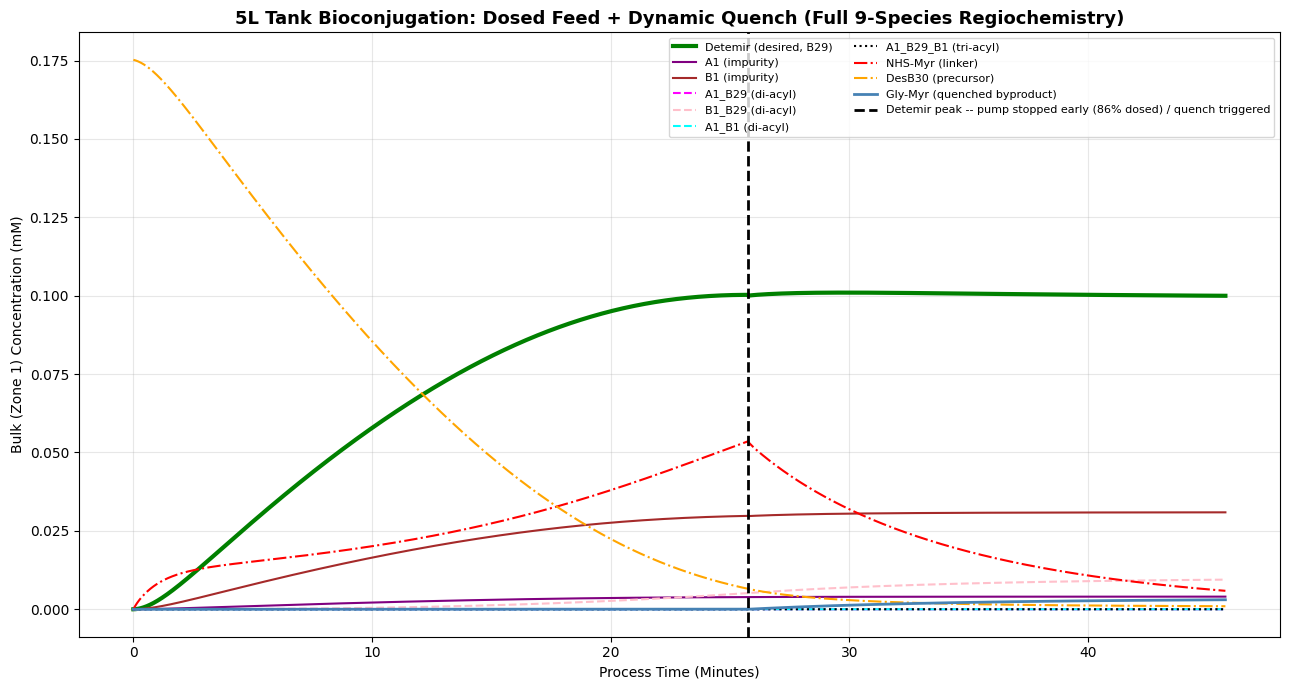

In [12]:
t2_min = t_grid2[:pk+1] / 60.0
t3_min = (sol3.t / 60.0) + t_peak_min
t_all_min = np.concatenate([t2_min, t3_min])

def bulk_stage2(name): return y_grid2[IDX[name], 0, :pk+1]
def bulk_stage3(name): return sol3.y.reshape(N_SPECIES, N_COMPARTMENTS, -1)[IDX[name], 0, :]
def bulk_full(name): return np.concatenate([bulk_stage2(name), bulk_stage3(name)])

# Convert to concentration for stage 2 (volume was time-varying there)
def bulk_conc_stage2(name):
    T_feed_s = T_FEED_MIN * 60.0
    out = np.zeros(pk+1)
    for i, t in enumerate(t_grid2[:pk+1]):
        V_added = min(t, T_feed_s) / T_feed_s * V_nhs_add_L
        V1c, _, _, _, _ = calc_compartments(V_start2 + V_added)
        out[i] = y_grid2[IDX[name], 0, i] / V1c
    return out

def bulk_conc_stage3(name):
    return sol3.y.reshape(N_SPECIES, N_COMPARTMENTS, -1)[IDX[name], 0, :] / V1f

def bulk_conc_full(name):
    return np.concatenate([bulk_conc_stage2(name), bulk_conc_stage3(name)])

plt.figure(figsize=(13, 7))
plt.plot(t_all_min, bulk_conc_full('detemir'), label='Detemir (desired, B29)', color='green', linewidth=3)
plt.plot(t_all_min, bulk_conc_full('A1'), label='A1 (impurity)', color='purple')
plt.plot(t_all_min, bulk_conc_full('B1'), label='B1 (impurity)', color='brown')
plt.plot(t_all_min, bulk_conc_full('A1_B29'), label='A1_B29 (di-acyl)', color='magenta', linestyle='--')
plt.plot(t_all_min, bulk_conc_full('B1_B29'), label='B1_B29 (di-acyl)', color='pink', linestyle='--')
plt.plot(t_all_min, bulk_conc_full('A1_B1'), label='A1_B1 (di-acyl)', color='cyan', linestyle='--')
plt.plot(t_all_min, bulk_conc_full('A1_B29_B1'), label='A1_B29_B1 (tri-acyl)', color='black', linestyle=':')
plt.plot(t_all_min, bulk_conc_full('nhs_myr'), label='NHS-Myr (linker)', color='red', linestyle='-.')
plt.plot(t_all_min, bulk_conc_full('desb30'), label='DesB30 (precursor)', color='orange', linestyle='-.')
plt.plot(t_all_min, bulk_conc_full('gly_myr'), label='Gly-Myr (quenched byproduct)', color='steelblue', linewidth=2)
plt.axvline(x=t_peak_min, color='black', linestyle='--', linewidth=2, label=f'Detemir peak -- pump stopped early ({pct_delivered:.0f}% dosed) / quench triggered')
plt.title('5L Tank Bioconjugation: Dosed Feed + Dynamic Quench (Full 9-Species Regiochemistry)', fontsize=13, fontweight='bold')
plt.xlabel('Process Time (Minutes)')
plt.ylabel('Bulk (Zone 1) Concentration (mM)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. SOP Summary -- Optimum Operating Conditions
Prints the process parameters your scientists need to write the SOP, derived directly from the optimization above.

In [13]:
pump_flow_rate_mL_min = (V_nhs_add_L * 1000.0) / T_FEED_MIN
nhs_delivered_mL = V_added_at_peak * 1000.0
nhs_delivered_mg = nhs_delivered_mL * NHS_STOCK_MG_ML
nhs_delivered_mmol = nhs_delivered_mg / MW_nhs_myr
actual_molar_excess = nhs_delivered_mmol / moles_desb30_mmol

gly_dose_mL = dose_gly_mmol * MW_glycine / GLY_STOCK_G_ML

detemir_final_mmol = final_state[IDX['detemir']].sum()
impurity_species = ['A1','B1','A1_B29','B1_B29','A1_B1','A1_B29_B1']
impurity_final_mmol = sum(final_state[IDX[s]].sum() for s in impurity_species)
yield_pct = detemir_final_mmol / moles_desb30_mmol * 100.0
purity_pct = detemir_final_mmol / (detemir_final_mmol + impurity_final_mmol) * 100.0
desb30_unreacted_mmol = final_state[IDX['desb30']].sum()
conversion_pct = (1.0 - desb30_unreacted_mmol/moles_desb30_mmol) * 100.0

print('='*70)
print('  5 L TANK MYRISTOYLATION -- OPTIMUM OPERATING CONDITIONS (SOP INPUTS)')
print('='*70)
print()
print('CHARGE / STOCK PREPARATION')
print(f'  DesB30 stock concentration:        {DESB30_STOCK_MG_ML:.3f} mg/mL')
print(f'  DesB30 charge (in buffer half):     {mass_desb30_mg:.2f} mg  ({moles_desb30_mmol:.5f} mmol)')
print(f'  NHS-Myr stock concentration:        {NHS_STOCK_MG_ML:.3f} mg/mL')
print(f'  NHS-Myr stock volume to prepare:     {V_nhs_add_L*1000:.1f} mL  (full 2.0x excess charge, {moles_nhs_mmol:.5f} mmol)')
print(f'  Glycine quench stock concentration: {GLY_STOCK_G_ML:.3f} g/mL')
print()
print('IMPELLER')
print(f'  Speed:                               {N_RPM:.0f} rpm  (45-deg PBT; confirmed no measurable')
print(f'                                        effect on yield/purity across 200-450 rpm)')
print()
print('NHS-MYR ADDITION (peristaltic pump)')
print(f'  Pump flow rate:                       {pump_flow_rate_mL_min:.2f} mL/min  (constant rate)')
print(f'  Nominal programmed feed duration:     {T_FEED_MIN:.1f} min')
print(f'  >>> ACTUAL pump STOP time:             {t_peak_min:.2f} min  (stop early - do NOT run full program)')
print(f'  NHS-Myr volume actually delivered:    {nhs_delivered_mL:.1f} mL  ({pct_delivered:.1f}% of prepared stock)')
print(f'  Actual molar excess delivered:        {actual_molar_excess:.2f}x  (vs 2.0x if fully dosed)')
print()
print('GLYCINE QUENCH')
print(f'  Trigger time:                         {t_peak_min:.2f} min (immediately after pump stop, at Detemir peak)')
print(f'  Dose:                                 {gly_dose_mL*1000:.1f} uL  ({dose_gly_mmol:.5f} mmol, '
      f'1.1x molar excess over residual NHS-Myr)')
print(f'  Residual NHS-Myr at trigger:          {nhs_residual:.5f} mmol')
print()
print('PREDICTED OUTCOME (at end of quench hold)')
print(f'  Detemir yield:                         {yield_pct:.1f}% of charged DesB30')
print(f'  Product purity (Detemir / total conj.): {purity_pct:.1f}%')
print(f'  DesB30 conversion:                      {conversion_pct:.1f}%')
print(f'  Total batch volume (post-quench):       {V_tot3:.3f} L')
print('='*70)

  5 L TANK MYRISTOYLATION -- OPTIMUM OPERATING CONDITIONS (SOP INPUTS)

CHARGE / STOCK PREPARATION
  DesB30 stock concentration:        2.000 mg/mL
  DesB30 charge (in buffer half):     3086.18 mg  (0.54087 mmol)
  NHS-Myr stock concentration:        0.482 mg/mL
  NHS-Myr stock volume to prepare:     730.4 mL  (full 2.0x excess charge, 1.08173 mmol)
  Glycine quench stock concentration: 2.000 g/mL

IMPELLER
  Speed:                               450 rpm  (45-deg PBT; confirmed no measurable
                                        effect on yield/purity across 200-450 rpm)

NHS-MYR ADDITION (peristaltic pump)
  Pump flow rate:                       24.35 mL/min  (constant rate)
  Nominal programmed feed duration:     30.0 min
  >>> ACTUAL pump STOP time:             25.76 min  (stop early - do NOT run full program)
  NHS-Myr volume actually delivered:    627.2 mL  (85.9% of prepared stock)
  Actual molar excess delivered:        1.72x  (vs 2.0x if fully dosed)

GLYCINE QUENCH
  Trigger 